In [1]:
import dolfinx
import ufl
from mpi4py import MPI
from petsc4py import PETSc

print("FEniCSx OK!")

FEniCSx OK!


# 05A — Single Well 1D Elasticity Simulation

Este é o primeiro notebook de simulação física do projeto.

Ele lê a camada:

```text
data/physics_ready/parquet/single_well_fenics_ready/
```

e executa uma primeira simulação 1D de elasticidade.

## Objetivo

Antes de entrar em poroelasticidade e termoporoelasticidade, precisamos validar o caminho mais simples:

```text
propriedades físicas do poço
↓
domínio 1D
↓
elasticidade
↓
deslocamento u(z)
↓
deformação ε(z)
↓
tensão σ(z)
```

## Por que começar com elasticidade 1D?

Porque ela é a base.

Se a elasticidade simples não estiver coerente, não faz sentido acoplar pressão, temperatura e fluxo.

## Entrada física

O notebook espera campos como:

```text
rho_kg_m3
vp_mps
vs_mps
nu
G_pa
K_pa
E_pa
```

## Saída

```text
data/simulation/parquet/single_well_elasticity_1d/
```

## Filosofia

Este notebook tem duas camadas:

1. **solver didático com NumPy**, para garantir que o estudo rode mesmo sem FEniCS instalado;
2. **ponte conceitual para FEniCS/FEniCSx**, para você entender como isso será migrado para PDE/FEM.

## Importante

Este notebook é o passo 05A.

Depois dele virão:

```text
05B — Poroelasticidade 1D
05C — Termoporoelasticidade 1D
```

# STEP 0 — Environment Setup

Carregamos bibliotecas e definimos diretórios.

Este notebook usa:

- pandas para carregar dados;
- numpy para cálculo numérico;
- matplotlib/seaborn para gráficos;
- um solver 1D simples para elasticidade.

O objetivo aqui é aprender a física, não complicar o ambiente.

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import List, Optional
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_PHYSICS_READY_DIR = Path("../data/physics_ready/parquet/single_well_fenics_ready")
DATA_SIMULATION_DIR = Path("../data/simulation/parquet/single_well_elasticity_1d")
REPORT_DIR = Path("../reports/single_well_elasticity_1d")

DATA_SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Se None, pega o physics-ready mais recente.
PHYSICS_READY_PARQUET_FILE: Optional[str] = None

# Parâmetros físicos iniciais da simulação.
# Vamos aplicar uma carga vertical compressiva no topo da zona.
# Pressão/tensão em Pascal.
APPLIED_TOP_STRESS_PA = -1.0e6  # -1 MPa compressivo

# Condição inferior: u = 0 na base.
BASE_DISPLACEMENT_M = 0.0

print("Ambiente preparado.")
print(f"DATA_PHYSICS_READY_DIR = {DATA_PHYSICS_READY_DIR.resolve()}")
print(f"DATA_SIMULATION_DIR    = {DATA_SIMULATION_DIR.resolve()}")
print(f"REPORT_DIR             = {REPORT_DIR.resolve()}")
print(f"APPLIED_TOP_STRESS_PA  = {APPLIED_TOP_STRESS_PA:,.3e} Pa")

Ambiente preparado.
DATA_PHYSICS_READY_DIR = /root/shared/data/physics_ready/parquet/single_well_fenics_ready
DATA_SIMULATION_DIR    = /root/shared/data/simulation/parquet/single_well_elasticity_1d
REPORT_DIR             = /root/shared/reports/single_well_elasticity_1d
APPLIED_TOP_STRESS_PA  = -1.000e+06 Pa


# STEP 1 — Load Physics-Ready Parquet

Agora carregamos o dataset preparado no notebook 04.

Esse arquivo já deve conter:

- malha regular de profundidade;
- densidade;
- Vp;
- Vs;
- Poisson;
- módulos elásticos;
- flag `physics_ready_valid`.

Esta é a entrada física da simulação.

In [3]:
def list_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet encontrado em: {data_dir.resolve()}")

    return files


def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print("Colunas duplicadas removidas mantendo a primeira ocorrência:")
        print(sorted(set(duplicated)))
    return df.loc[:, ~df.columns.duplicated()].copy()


physics_files = list_parquet_files(DATA_PHYSICS_READY_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in physics_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in physics_files],
}))

if PHYSICS_READY_PARQUET_FILE is None:
    selected_physics_path = physics_files[0]
else:
    selected_physics_path = DATA_PHYSICS_READY_DIR / PHYSICS_READY_PARQUET_FILE
    if not selected_physics_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_physics_path}")

df = pd.read_parquet(selected_physics_path)
df = make_unique_columns(df).sort_values("DEPTH").reset_index(drop=True)

if "WELL" in df.columns and df["WELL"].notna().any():
    WELL_NAME = str(df["WELL"].dropna().iloc[0])
else:
    WELL_NAME = selected_physics_path.stem.split("_fenics_ready")[0]

print(f"Arquivo physics-ready selecionado: {selected_physics_path.name}")
print(f"Poço: {WELL_NAME}")
print(f"Shape: {df.shape}")
print(f"Depth min: {df['DEPTH'].min():,.3f}")
print(f"Depth max: {df['DEPTH'].max():,.3f}")

display(df.head())
display(df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_fenics_ready_2350m1_2400m0.parquet,2026-05-08 14:48:38.060850382


Arquivo physics-ready selecionado: TFT-4_fenics_ready_2350m1_2400m0.parquet
Poço: TFT-4
Shape: (329, 16)
Depth min: 2,350.136
Depth max: 2,399.992


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
0,TFT-4,"2,350.136400","2,409.744322","4,564.744311","2,251.323467",0.334331,"12,256,840,817.437845","33,003,964,238.271610","32,786,153,018.229519","10,988,331.988865","5,424,147.760899",0.219376,"2,350.136400","2,399.992400",0.152000,True
1,TFT-4,"2,350.288400","2,409.362810","4,515.308239","2,218.423544",0.335592,"11,913,293,372.311029","32,545,065,165.444843","31,905,485,503.589760","10,872,226.132795","5,345,663.917131",0.251638,"2,350.136400","2,399.992400",0.152000,True
2,TFT-4,"2,350.440400","2,409.240171","4,464.553345","2,188.575913",0.336538,"11,605,362,566.700142","31,991,636,763.882751","31,103,994,897.294281","10,751,782.908020","5,274,144.908529",0.286587,"2,350.136400","2,399.992400",0.152000,True
3,TFT-4,"2,350.592400","2,409.144786","4,404.476525","2,157.580660",0.337273,"11,293,693,500.715904","31,261,745,368.586189","30,277,976,074.992485","10,609,289.794359","5,200,176.422041",0.318953,"2,350.136400","2,399.992400",0.152000,True
4,TFT-4,"2,350.744400","2,408.905709","4,337.697166","2,129.403432",0.337862,"11,010,394,982.113462","30,394,247,432.326649","29,503,347,628.122078","10,446,856.563887","5,131,202.094845",0.345972,"2,350.136400","2,399.992400",0.152000,True


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
324,TFT-4,"2,399.384400","2,425.259936","3,417.817492","1,865.594885",0.288048,"8,461,479,016.900890","16,970,268,536.367668","21,768,744,085.145435","8,269,377.572994","4,522,558.092900",0.596667,"2,350.136400","2,399.992400",0.152000,True
325,TFT-4,"2,399.536400","2,429.335634","3,428.954997","1,871.179920",0.288117,"8,530,592,123.557176","17,114,040,401.184122","21,941,982,585.864567","8,307,618.998616","4,545,282.536272",0.596311,"2,350.136400","2,399.992400",0.152000,True
326,TFT-4,"2,399.688400","2,434.430257","3,442.876878","1,878.114600",0.288204,"8,613,100,959.222910","17,293,755,232.205284","22,156,411,146.318531","8,355,420.780645","4,572,694.585376",0.595866,"2,350.136400","2,399.992400",0.152000,True
327,TFT-4,"2,399.840400","2,437.703252","3,460.776439","1,886.508270",0.288315,"8,701,405,940.235632","17,524,817,157.804939","22,397,248,085.329918","8,414,959.192313","4,602,911.181458",0.596467,"2,350.136400","2,399.992400",0.152000,True
328,TFT-4,"2,399.992400","2,439.323485","3,484.642521","1,897.699829",0.288398,"8,818,103,024.547861","17,832,899,725.233055","22,718,364,003.972057","8,490,158.764764","4,635,465.171205",0.597377,"2,350.136400","2,399.992400",0.152000,True


# STEP 2 — Physics-Ready Audit

Antes de simular, verificamos se os campos necessários existem e estão preenchidos.

Para elasticidade 1D, o campo principal é:

```text
E(z)
```

e, para análises complementares:

```text
nu(z)
rho(z)
G(z)
K(z)
```

Neste primeiro modelo quase-estático 1D, usaremos principalmente `E_pa`.

,FIELD,EXISTS,NON_NULL,FILL_RATE,MIN,MAX
0,DEPTH,True,329,1.000000,"2,350.136400","2,399.992400"
1,rho_kg_m3,True,329,1.000000,"2,369.907271","2,531.487963"
2,vp_mps,True,329,1.000000,"3,226.722407","4,564.744311"
3,vs_mps,True,329,1.000000,"1,739.637748","2,251.323467"
4,nu,True,329,1.000000,0.276675,0.340634
5,G_pa,True,329,1.000000,"7,226,831,727.753093","12,256,840,817.437845"
6,K_pa,True,329,1.000000,"14,991,619,130.685730","33,003,964,238.271610"
7,E_pa,True,329,1.000000,"18,722,214,064.785511","32,786,153,018.229519"
8,physics_ready_valid,True,329,1.000000,1.000000,1.000000


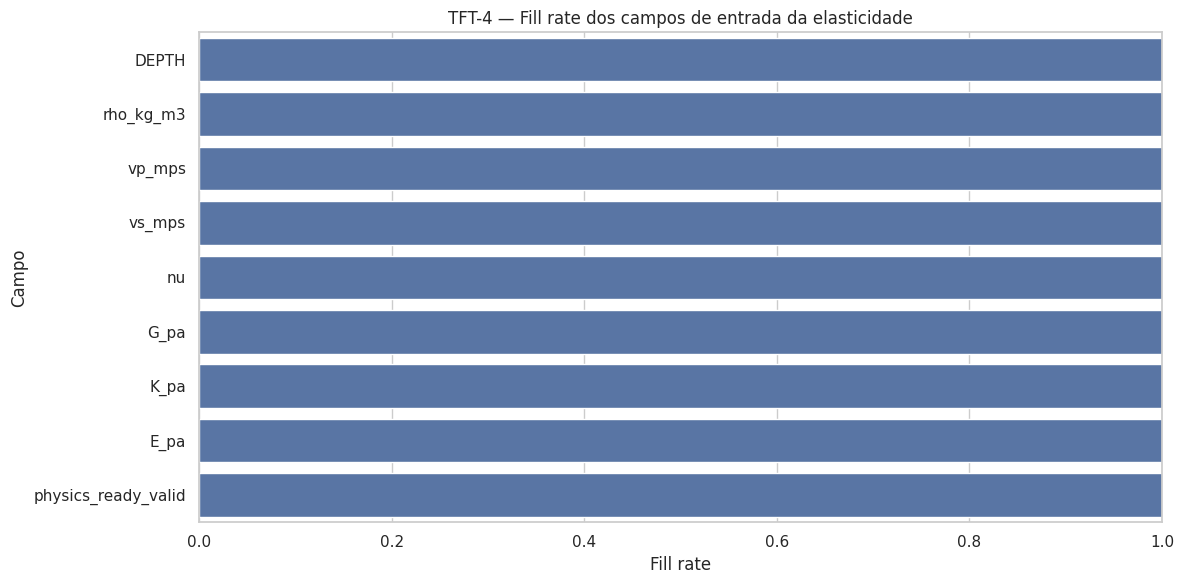


## Interpretação

Esta auditoria pergunta:

> O dataset physics-ready está realmente pronto para uma simulação elástica?

O campo crítico para este primeiro modelo é `E_pa`.

Se `E_pa` estiver bem preenchido e fisicamente válido, conseguimos resolver uma elasticidade 1D simples.

`nu`, `G_pa` e `K_pa` serão fundamentais quando avançarmos para modelos mais ricos.


In [4]:
required_cols = [
    "DEPTH",
    "rho_kg_m3",
    "vp_mps",
    "vs_mps",
    "nu",
    "G_pa",
    "K_pa",
    "E_pa",
    "physics_ready_valid",
]

rows = []
for col in required_cols:
    exists = col in df.columns
    if exists:
        if col == "physics_ready_valid":
            s = df[col].astype(float)
        else:
            s = pd.to_numeric(df[col], errors="coerce")
        rows.append({
            "FIELD": col,
            "EXISTS": exists,
            "NON_NULL": int(s.notna().sum()),
            "FILL_RATE": float(s.notna().mean()),
            "MIN": s.min(),
            "MAX": s.max(),
        })
    else:
        rows.append({
            "FIELD": col,
            "EXISTS": exists,
            "NON_NULL": 0,
            "FILL_RATE": 0.0,
            "MIN": np.nan,
            "MAX": np.nan,
        })

audit_df = pd.DataFrame(rows)
display(audit_df)
audit_df.to_csv(REPORT_DIR / f"{WELL_NAME}_elasticity_input_audit.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=audit_df[audit_df["EXISTS"]].sort_values("FILL_RATE"), y="FIELD", x="FILL_RATE", orient="h")
plt.title(f"{WELL_NAME} — Fill rate dos campos de entrada da elasticidade")
plt.xlabel("Fill rate")
plt.ylabel("Campo")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(Markdown('''
## Interpretação

Esta auditoria pergunta:

> O dataset physics-ready está realmente pronto para uma simulação elástica?

O campo crítico para este primeiro modelo é `E_pa`.

Se `E_pa` estiver bem preenchido e fisicamente válido, conseguimos resolver uma elasticidade 1D simples.

`nu`, `G_pa` e `K_pa` serão fundamentais quando avançarmos para modelos mais ricos.
'''))

# STEP 3 — Keep Only Valid Physics Points

Se existir a coluna `physics_ready_valid`, usamos apenas pontos válidos.

Isso evita que o solver receba valores fisicamente ruins.

In [5]:
work_df = df.copy()

if "physics_ready_valid" in work_df.columns:
    valid_mask = work_df["physics_ready_valid"].fillna(False).astype(bool)
else:
    valid_mask = pd.Series(True, index=work_df.index)

sim_df = work_df.loc[valid_mask].copy()
sim_df = sim_df.dropna(subset=["DEPTH", "E_pa"]).sort_values("DEPTH").reset_index(drop=True)

print(f"Pontos originais: {len(work_df):,}")
print(f"Pontos válidos para simulação: {len(sim_df):,}")
print(f"Taxa usada: {len(sim_df) / len(work_df):.2%}")

display(sim_df.head())
display(sim_df.tail())

if len(sim_df) < 5:
    raise ValueError("Poucos pontos válidos para simulação. Revise o notebook 04 ou escolha outra zona.")

display(Markdown(f'''
## Interpretação

- Pontos originais: **{len(work_df):,}**
- Pontos usados na simulação: **{len(sim_df):,}**

A simulação deve usar apenas pontos fisicamente válidos.

Se a taxa usada for alta, ótimo.  
Se for baixa, a zona ou os filtros precisam ser revisados.
'''))

Pontos originais: 329
Pontos válidos para simulação: 329
Taxa usada: 100.00%


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
0,TFT-4,"2,350.136400","2,409.744322","4,564.744311","2,251.323467",0.334331,"12,256,840,817.437845","33,003,964,238.271610","32,786,153,018.229519","10,988,331.988865","5,424,147.760899",0.219376,"2,350.136400","2,399.992400",0.152000,True
1,TFT-4,"2,350.288400","2,409.362810","4,515.308239","2,218.423544",0.335592,"11,913,293,372.311029","32,545,065,165.444843","31,905,485,503.589760","10,872,226.132795","5,345,663.917131",0.251638,"2,350.136400","2,399.992400",0.152000,True
2,TFT-4,"2,350.440400","2,409.240171","4,464.553345","2,188.575913",0.336538,"11,605,362,566.700142","31,991,636,763.882751","31,103,994,897.294281","10,751,782.908020","5,274,144.908529",0.286587,"2,350.136400","2,399.992400",0.152000,True
3,TFT-4,"2,350.592400","2,409.144786","4,404.476525","2,157.580660",0.337273,"11,293,693,500.715904","31,261,745,368.586189","30,277,976,074.992485","10,609,289.794359","5,200,176.422041",0.318953,"2,350.136400","2,399.992400",0.152000,True
4,TFT-4,"2,350.744400","2,408.905709","4,337.697166","2,129.403432",0.337862,"11,010,394,982.113462","30,394,247,432.326649","29,503,347,628.122078","10,446,856.563887","5,131,202.094845",0.345972,"2,350.136400","2,399.992400",0.152000,True


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
324,TFT-4,"2,399.384400","2,425.259936","3,417.817492","1,865.594885",0.288048,"8,461,479,016.900890","16,970,268,536.367668","21,768,744,085.145435","8,269,377.572994","4,522,558.092900",0.596667,"2,350.136400","2,399.992400",0.152000,True
325,TFT-4,"2,399.536400","2,429.335634","3,428.954997","1,871.179920",0.288117,"8,530,592,123.557176","17,114,040,401.184122","21,941,982,585.864567","8,307,618.998616","4,545,282.536272",0.596311,"2,350.136400","2,399.992400",0.152000,True
326,TFT-4,"2,399.688400","2,434.430257","3,442.876878","1,878.114600",0.288204,"8,613,100,959.222910","17,293,755,232.205284","22,156,411,146.318531","8,355,420.780645","4,572,694.585376",0.595866,"2,350.136400","2,399.992400",0.152000,True
327,TFT-4,"2,399.840400","2,437.703252","3,460.776439","1,886.508270",0.288315,"8,701,405,940.235632","17,524,817,157.804939","22,397,248,085.329918","8,414,959.192313","4,602,911.181458",0.596467,"2,350.136400","2,399.992400",0.152000,True
328,TFT-4,"2,399.992400","2,439.323485","3,484.642521","1,897.699829",0.288398,"8,818,103,024.547861","17,832,899,725.233055","22,718,364,003.972057","8,490,158.764764","4,635,465.171205",0.597377,"2,350.136400","2,399.992400",0.152000,True



## Interpretação

- Pontos originais: **329**
- Pontos usados na simulação: **329**

A simulação deve usar apenas pontos fisicamente válidos.

Se a taxa usada for alta, ótimo.  
Se for baixa, a zona ou os filtros precisam ser revisados.


# STEP 4 — Convert Depth to Local Coordinate

A profundidade do poço pode estar em metros medidos.

Para simulação 1D, é mais confortável criar uma coordenada local:

```text
x = DEPTH - DEPTH_MIN
```

Assim:

```text
x = 0
```

representa o topo da zona, e o final representa a base da zona.

## Convenção deste notebook

- `x = 0`: topo da zona;
- `x = L`: base da zona;
- deslocamento positivo: sentido crescente de profundidade;
- tensão compressiva aplicada no topo: negativa.

Comprimento físico da zona L = 49.856000 m
Número de pontos N = 329
dx mediano = 0.152000 m


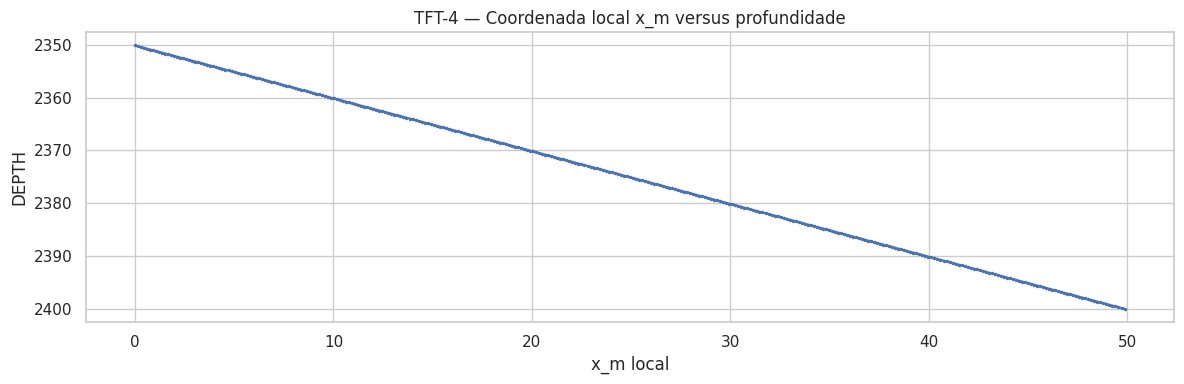


## Interpretação

A zona selecionada foi convertida para uma coordenada local.

- Comprimento da zona: **49.8560 m**
- Pontos na malha: **329**
- Espaçamento mediano: **0.152000 m**

Agora o poço virou um domínio físico 1D.


In [6]:
sim_df["x_m"] = sim_df["DEPTH"] - sim_df["DEPTH"].min()

L = float(sim_df["x_m"].max())
N = len(sim_df)

print(f"Comprimento físico da zona L = {L:,.6f} m")
print(f"Número de pontos N = {N:,}")

dx_values = sim_df["x_m"].diff().dropna()
dx_median = dx_values[dx_values > 0].median()

print(f"dx mediano = {dx_median:,.6f} m")

plt.figure(figsize=(12, 4))
plt.plot(sim_df["x_m"], sim_df["DEPTH"], ".-", markersize=3)
plt.gca().invert_yaxis()
plt.title(f"{WELL_NAME} — Coordenada local x_m versus profundidade")
plt.xlabel("x_m local")
plt.ylabel("DEPTH")
plt.tight_layout()
plt.show()

display(Markdown(f'''
## Interpretação

A zona selecionada foi convertida para uma coordenada local.

- Comprimento da zona: **{L:,.4f} m**
- Pontos na malha: **{N:,}**
- Espaçamento mediano: **{dx_median:,.6f} m**

Agora o poço virou um domínio físico 1D.
'''))

# STEP 5 — Plot Elastic Input Fields

Antes de resolver a física, olhamos os campos de entrada.

Principalmente:

```text
E(z)
nu(z)
rho(z)
G(z)
K(z)
```

Estes campos dizem como a rocha muda ao longo da zona.

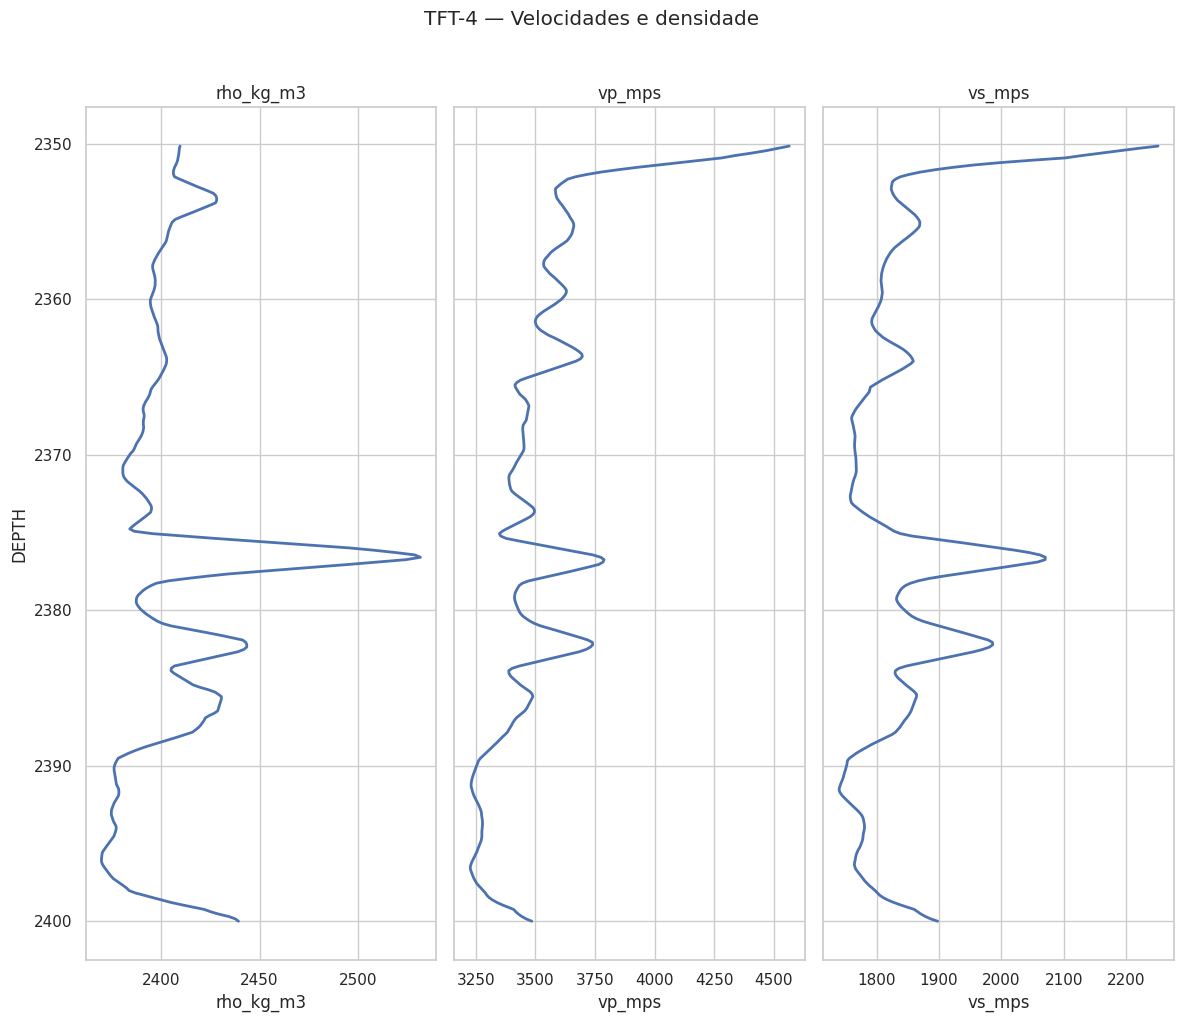

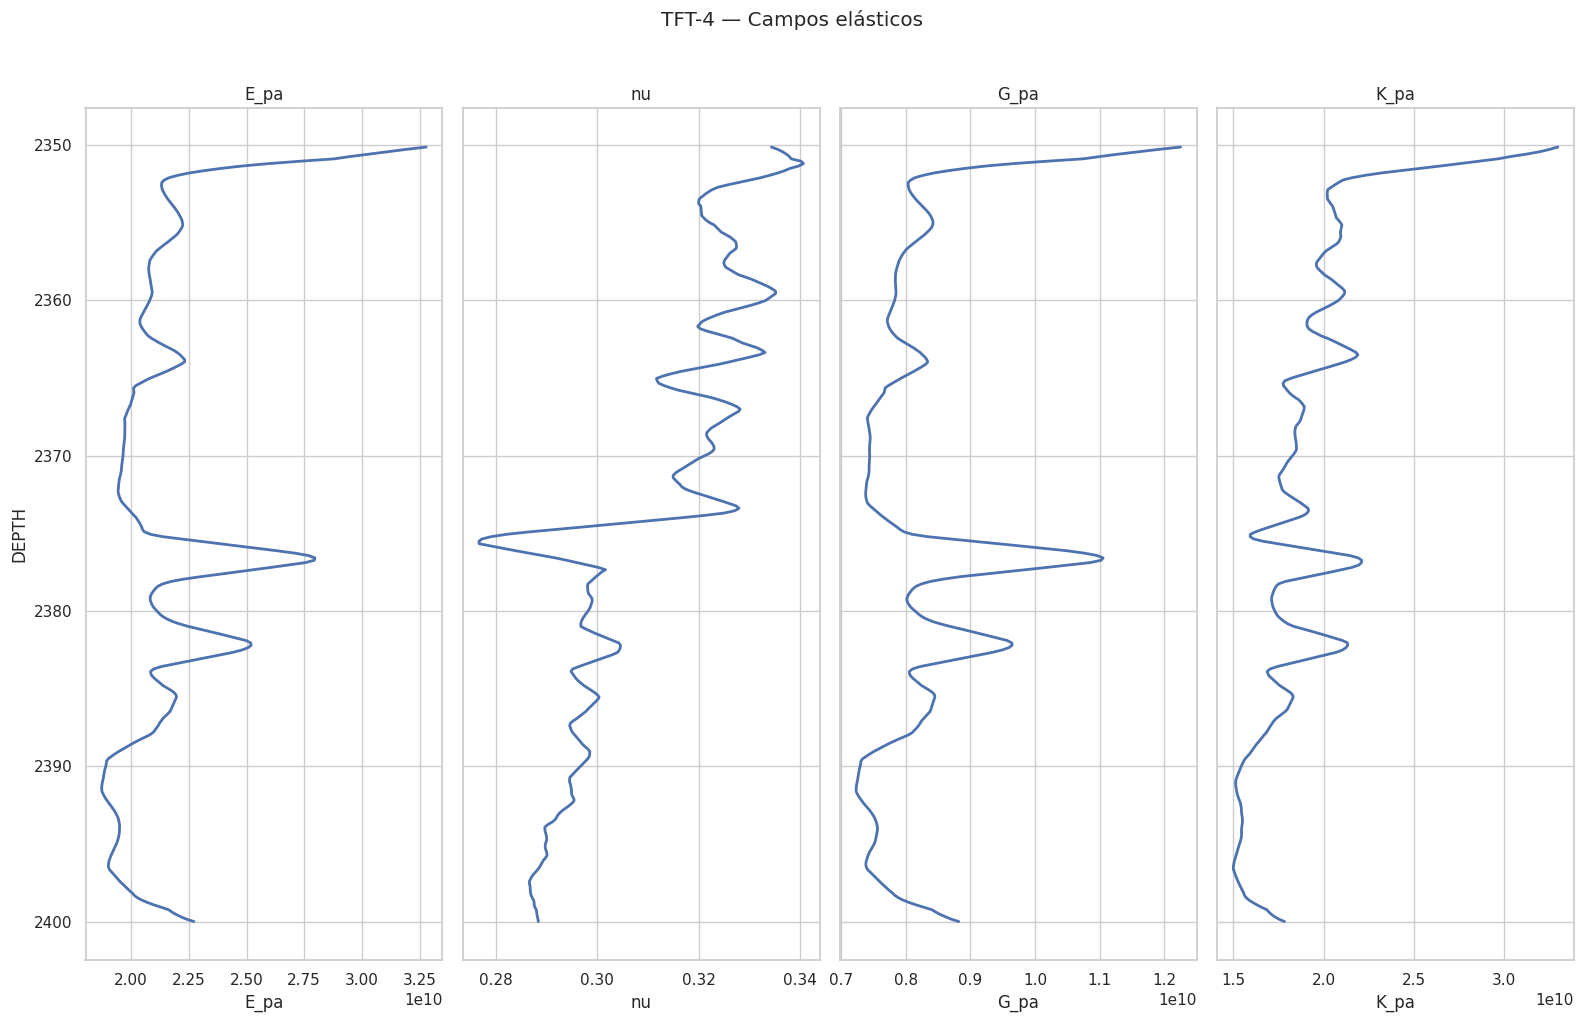

,count,mean,std,min,25%,50%,75%,max
rho_kg_m3,329.000000,"2,402.494296",26.101661,"2,369.907271","2,387.120095","2,396.895885","2,410.296202","2,531.487963"
vp_mps,329.000000,"3,489.382272",201.753099,"3,226.722407","3,388.645748","3,456.592263","3,590.366431","4,564.744311"
vs_mps,329.000000,"1,831.354559",80.856423,"1,739.637748","1,772.921882","1,815.303163","1,854.726056","2,251.323467"
E_pa,329.000000,"21,180,148,620.146412","2,198,547,857.700233","18,722,214,064.785511","19,671,270,865.790203","20,828,348,318.486313","21,779,705,723.975765","32,786,153,018.229519"
nu,329.000000,0.308961,0.016427,0.276675,0.295193,0.304024,0.323925,0.340634
G_pa,329.000000,"8,097,526,066.473323","846,222,181.201872","7,226,831,727.753093","7,490,406,462.766688","7,895,230,028.795199","8,305,742,738.458840","12,256,840,817.437845"
K_pa,329.000000,"18,602,707,594.774769","2,857,252,041.103052","14,991,619,130.685730","16,878,042,345.095726","18,268,591,440.712395","20,218,452,209.536900","33,003,964,238.271610"



## Interpretação

Aqui vemos o material que será usado pela simulação.

### O que observar

- `E_pa` alto: rocha mais rígida.
- `E_pa` baixo: rocha mais deformável.
- `nu` alto: comportamento mais dúctil/incompressível.
- `nu` baixo: comportamento potencialmente mais frágil.
- `G_pa` alto: maior resistência ao cisalhamento.
- `K_pa` alto: maior resistência à compressão volumétrica.

A simulação elástica vai responder diretamente a estes campos.


In [7]:
def plot_input_fields(df: pd.DataFrame, fields: List[str], title: str) -> None:
    fields = [f for f in fields if f in df.columns and df[f].notna().any()]
    if not fields:
        print("Nenhum campo disponível.")
        return

    fig, axes = plt.subplots(1, len(fields), figsize=(4 * len(fields), 10), sharey=True)
    if len(fields) == 1:
        axes = [axes]

    for ax, field in zip(axes, fields):
        ax.plot(df[field], df["DEPTH"], "-", linewidth=2)
        ax.set_title(field)
        ax.set_xlabel(field)
        ax.grid(True)

    axes[0].invert_yaxis()
    axes[0].set_ylabel("DEPTH")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_input_fields(sim_df, ["rho_kg_m3", "vp_mps", "vs_mps"], f"{WELL_NAME} — Velocidades e densidade")
plot_input_fields(sim_df, ["E_pa", "nu", "G_pa", "K_pa"], f"{WELL_NAME} — Campos elásticos")

input_stats = sim_df[["rho_kg_m3", "vp_mps", "vs_mps", "E_pa", "nu", "G_pa", "K_pa"]].describe().T
display(input_stats)

display(Markdown('''
## Interpretação

Aqui vemos o material que será usado pela simulação.

### O que observar

- `E_pa` alto: rocha mais rígida.
- `E_pa` baixo: rocha mais deformável.
- `nu` alto: comportamento mais dúctil/incompressível.
- `nu` baixo: comportamento potencialmente mais frágil.
- `G_pa` alto: maior resistência ao cisalhamento.
- `K_pa` alto: maior resistência à compressão volumétrica.

A simulação elástica vai responder diretamente a estes campos.
'''))

# STEP 6 — Physical Model: 1D Static Elasticity

Agora definimos o modelo físico.

Para uma barra 1D heterogênea, em equilíbrio estático:

```text
dσ/dx + f = 0
```

Se ignorarmos força de corpo no primeiro experimento:

```text
dσ/dx = 0
```

A tensão é aproximadamente constante no domínio.

A relação constitutiva 1D é:

```text
σ(x) = E(x) * ε(x)
```

e a deformação é:

```text
ε(x) = du/dx
```

Logo:

```text
du/dx = σ / E(x)
```

Se aplicarmos uma tensão compressiva no topo e fixarmos a base, conseguimos calcular o deslocamento acumulado.

## Condições de contorno

- Base fixa:

```text
u(L) = 0
```

- Tensão aplicada no topo:

```text
σ(0) = σ_top
```

Este primeiro modelo é simples, mas extremamente didático.

In [8]:
display(Markdown(f'''
## Parâmetros da simulação

- Tensão aplicada no topo: **{APPLIED_TOP_STRESS_PA:,.3e} Pa**
- Deslocamento fixo na base: **{BASE_DISPLACEMENT_M:,.3e} m**

### Interpretação física

Como a tensão é compressiva, esperamos deformação compressiva.

Em regiões com `E_pa` menor, a deformação local será maior.

Em regiões com `E_pa` maior, a deformação local será menor.
'''))


## Parâmetros da simulação

- Tensão aplicada no topo: **-1.000e+06 Pa**
- Deslocamento fixo na base: **0.000e+00 m**

### Interpretação física

Como a tensão é compressiva, esperamos deformação compressiva.

Em regiões com `E_pa` menor, a deformação local será maior.

Em regiões com `E_pa` maior, a deformação local será menor.


# STEP 7 — NumPy Solver for 1D Elasticity

Agora resolvemos o problema com NumPy.

Este solver é didático e direto.

## Ideia

Como:

```text
ε(x) = σ / E(x)
```

e:

```text
ε = du/dx
```

integramos a deformação ao longo da profundidade.

Com a base fixa em `u(L)=0`, calculamos o deslocamento relativo em cada ponto.

## Por que isto é útil?

Porque te mostra claramente como `E(z)` controla a deformação e deslocamento.

In [9]:
# Campos físicos
x = sim_df["x_m"].to_numpy(dtype=float)
depth = sim_df["DEPTH"].to_numpy(dtype=float)
E = sim_df["E_pa"].to_numpy(dtype=float)

# Tensão constante aplicada.
sigma = np.full_like(x, APPLIED_TOP_STRESS_PA, dtype=float)

# Deformação local.
# epsilon = sigma / E
epsilon = sigma / E

# Integração de epsilon para obter u.
# Queremos u(L)=BASE_DISPLACEMENT_M.
# Calculamos de baixo para cima.
u = np.zeros_like(x, dtype=float)
u[-1] = BASE_DISPLACEMENT_M

# Integração reversa:
# du = epsilon * dx
# u[i] = u[i+1] - integral de epsilon entre i e i+1
for i in range(len(x) - 2, -1, -1):
    dx = x[i + 1] - x[i]
    eps_avg = 0.5 * (epsilon[i + 1] + epsilon[i])
    u[i] = u[i + 1] - eps_avg * dx

# Tensão recalculada para conferência.
sigma_check = E * np.gradient(u, x)

result_df = sim_df.copy()
result_df["u_m"] = u
result_df["epsilon"] = epsilon
result_df["sigma_pa"] = sigma
result_df["sigma_check_pa"] = sigma_check
result_df["abs_u_m"] = result_df["u_m"].abs()

display(result_df[["DEPTH", "x_m", "E_pa", "u_m", "epsilon", "sigma_pa", "sigma_check_pa"]].head())
display(result_df[["DEPTH", "x_m", "E_pa", "u_m", "epsilon", "sigma_pa", "sigma_check_pa"]].tail())

summary = pd.DataFrame([{
    "WELL": WELL_NAME,
    "N_POINTS": len(result_df),
    "L_M": L,
    "APPLIED_TOP_STRESS_PA": APPLIED_TOP_STRESS_PA,
    "BASE_DISPLACEMENT_M": BASE_DISPLACEMENT_M,
    "U_TOP_M": result_df["u_m"].iloc[0],
    "U_BASE_M": result_df["u_m"].iloc[-1],
    "MAX_ABS_U_M": result_df["abs_u_m"].max(),
    "EPSILON_MIN": result_df["epsilon"].min(),
    "EPSILON_MAX": result_df["epsilon"].max(),
    "E_MIN_PA": result_df["E_pa"].min(),
    "E_MAX_PA": result_df["E_pa"].max(),
}])

display(summary)

display(Markdown(f'''
## Interpretação do solver

O solver aplicou uma tensão vertical constante de **{APPLIED_TOP_STRESS_PA:,.3e} Pa** e calculou a deformação local:

```text
epsilon = sigma / E
```

### Resultado principal

- Deslocamento no topo: **{result_df["u_m"].iloc[0]:,.6e} m**
- Deslocamento na base: **{result_df["u_m"].iloc[-1]:,.6e} m**
- Máximo deslocamento absoluto: **{result_df["abs_u_m"].max():,.6e} m**
- Deformação mínima: **{result_df["epsilon"].min():,.6e}**
- Deformação máxima: **{result_df["epsilon"].max():,.6e}**

### Como interpretar

Como a base está fixa, o topo acumula o deslocamento produzido pela deformação ao longo da zona.

Onde `E_pa` é menor, a rocha deforma mais.

Onde `E_pa` é maior, a rocha resiste mais.
'''))

,DEPTH,x_m,E_pa,u_m,epsilon,sigma_pa,sigma_check_pa
0,"2,350.136400",0.000000,"32,786,153,018.229519",0.002377,-0.000031,"-1,000,000.000000","-1,013,801.192816"
1,"2,350.288400",0.152000,"31,905,485,503.589760",0.002372,-0.000031,"-1,000,000.000000","-999,726.783264"
2,"2,350.440400",0.304000,"31,103,994,897.294281",0.002367,-0.000032,"-1,000,000.000000","-1,000,540.099826"
3,"2,350.592400",0.456000,"30,277,976,074.992485",0.002362,-0.000033,"-1,000,000.000000","-999,924.733126"
4,"2,350.744400",0.608000,"29,503,347,628.122078",0.002357,-0.000034,"-1,000,000.000000","-999,785.405124"


,DEPTH,x_m,E_pa,u_m,epsilon,sigma_pa,sigma_check_pa
324,"2,399.384400",49.248000,"21,768,744,085.145435",0.000027,-0.000046,"-1,000,000.000000","-999,719.397521"
325,"2,399.536400",49.400000,"21,941,982,585.864567",0.000020,-0.000046,"-1,000,000.000000","-999,570.045951"
326,"2,399.688400",49.552000,"22,156,411,146.318531",0.000014,-0.000045,"-1,000,000.000000","-999,754.888578"
327,"2,399.840400",49.704000,"22,397,248,085.329918",0.000007,-0.000045,"-1,000,000.000000","-999,183.803084"
328,"2,399.992400",49.856000,"22,718,364,003.972057",0.000000,-0.000044,"-1,000,000.000000","-1,007,168.646733"


,WELL,N_POINTS,L_M,APPLIED_TOP_STRESS_PA,BASE_DISPLACEMENT_M,U_TOP_M,U_BASE_M,MAX_ABS_U_M,EPSILON_MIN,EPSILON_MAX,E_MIN_PA,E_MAX_PA
0,TFT-4,329,49.856000,"-1,000,000.000000",0.000000,0.002377,0.000000,0.002377,-0.000053,-0.000031,"18,722,214,064.785511","32,786,153,018.229519"



## Interpretação do solver

O solver aplicou uma tensão vertical constante de **-1.000e+06 Pa** e calculou a deformação local:

```text
epsilon = sigma / E
```

### Resultado principal

- Deslocamento no topo: **2.376728e-03 m**
- Deslocamento na base: **0.000000e+00 m**
- Máximo deslocamento absoluto: **2.376728e-03 m**
- Deformação mínima: **-5.341249e-05**
- Deformação máxima: **-3.050068e-05**

### Como interpretar

Como a base está fixa, o topo acumula o deslocamento produzido pela deformação ao longo da zona.

Onde `E_pa` é menor, a rocha deforma mais.

Onde `E_pa` é maior, a rocha resiste mais.


# STEP 8 — Plot Simulation Results

Agora visualizamos:

- deslocamento `u`;
- deformação `epsilon`;
- tensão `sigma`;
- módulo de Young `E`.

Esta é a primeira resposta física simulada do poço.

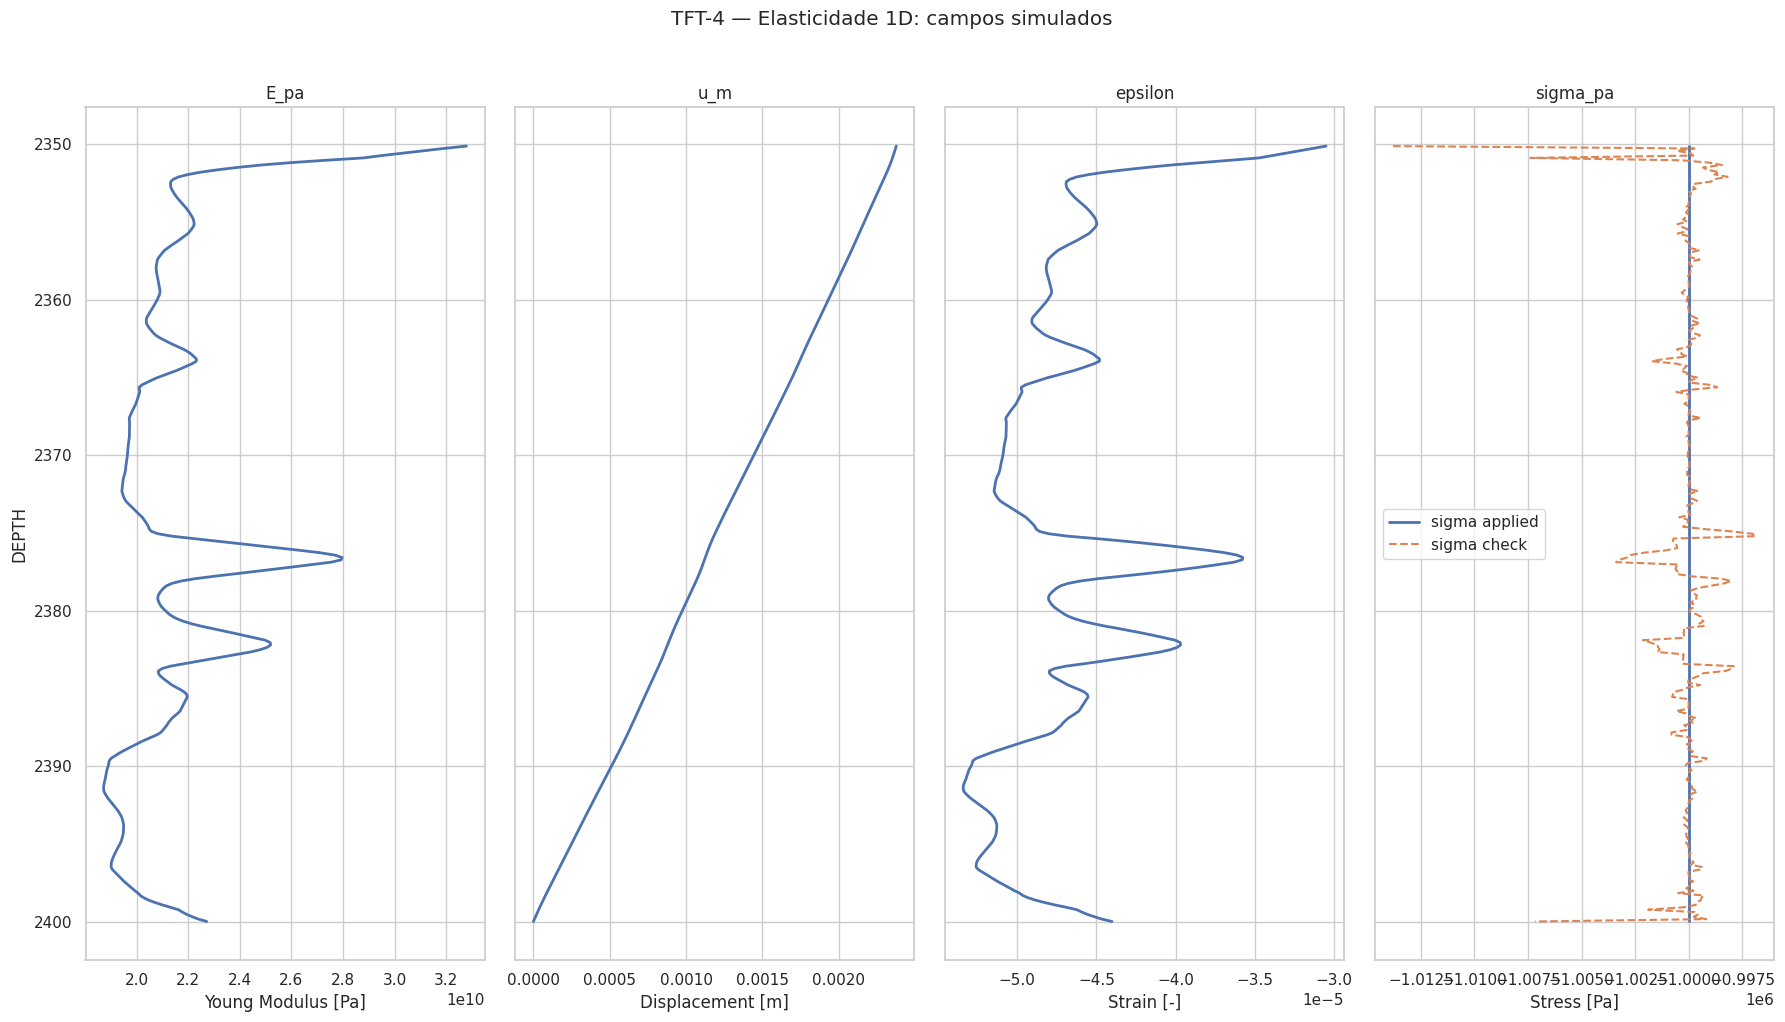


## Interpretação dos resultados simulados

### E_pa

Mostra a rigidez da rocha.

- E alto: menor deformação.
- E baixo: maior deformação.

### u_m

Mostra o deslocamento acumulado.

Como a base está fixa, o deslocamento cresce em direção ao topo.

### epsilon

Mostra a deformação local.

Ela é mais intensa onde o módulo de Young é menor.

### sigma

Neste primeiro modelo, a tensão é aproximadamente constante porque não adicionamos força de corpo nem acoplamento com pressão.

### Conclusão

Este é o primeiro “pulso” físico do poço: o dado petrofísico virou resposta mecânica.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 10), sharey=True)

axes[0].plot(result_df["E_pa"], result_df["DEPTH"], "-", linewidth=2)
axes[0].set_title("E_pa")
axes[0].set_xlabel("Young Modulus [Pa]")

axes[1].plot(result_df["u_m"], result_df["DEPTH"], "-", linewidth=2)
axes[1].set_title("u_m")
axes[1].set_xlabel("Displacement [m]")

axes[2].plot(result_df["epsilon"], result_df["DEPTH"], "-", linewidth=2)
axes[2].set_title("epsilon")
axes[2].set_xlabel("Strain [-]")

axes[3].plot(result_df["sigma_pa"], result_df["DEPTH"], "-", linewidth=2, label="sigma applied")
axes[3].plot(result_df["sigma_check_pa"], result_df["DEPTH"], "--", linewidth=1.5, label="sigma check")
axes[3].set_title("sigma_pa")
axes[3].set_xlabel("Stress [Pa]")
axes[3].legend()

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("DEPTH")
fig.suptitle(f"{WELL_NAME} — Elasticidade 1D: campos simulados", y=1.02)
plt.tight_layout()
plt.show()

display(Markdown('''
## Interpretação dos resultados simulados

### E_pa

Mostra a rigidez da rocha.

- E alto: menor deformação.
- E baixo: maior deformação.

### u_m

Mostra o deslocamento acumulado.

Como a base está fixa, o deslocamento cresce em direção ao topo.

### epsilon

Mostra a deformação local.

Ela é mais intensa onde o módulo de Young é menor.

### sigma

Neste primeiro modelo, a tensão é aproximadamente constante porque não adicionamos força de corpo nem acoplamento com pressão.

### Conclusão

Este é o primeiro “pulso” físico do poço: o dado petrofísico virou resposta mecânica.
'''))

# STEP 9 — Relation Between Stiffness and Strain

Agora validamos a relação física esperada.

Como:

```text
epsilon = sigma / E
```

se `E` aumenta, `epsilon` deve diminuir em magnitude.

Esse gráfico é uma checagem de sanidade física.

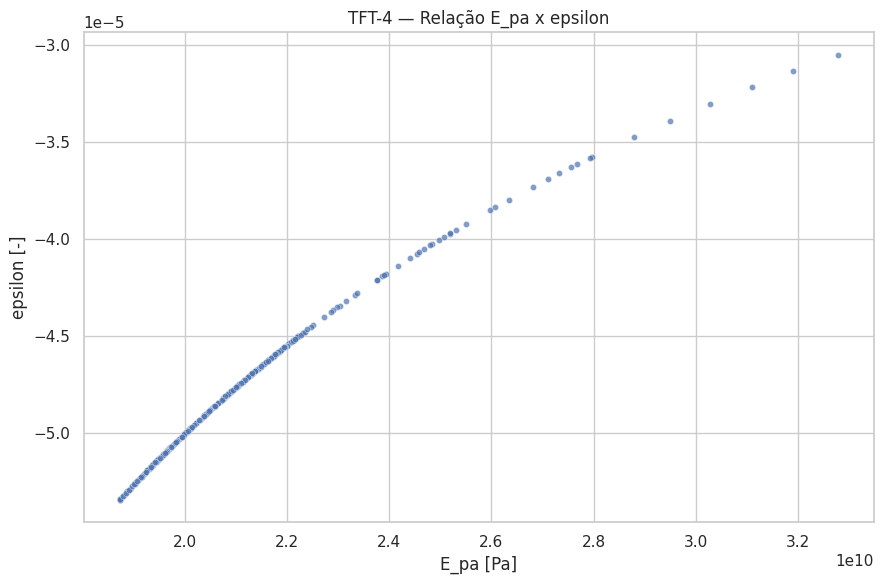


## Interpretação

Correlação Spearman entre `E_pa` e `epsilon`: **1.0000**

Como a tensão aplicada é constante, esperamos uma relação inversa:

```text
E maior  -> deformação menor em magnitude
E menor  -> deformação maior em magnitude
```

Como a tensão é negativa compressiva, a deformação também é negativa.  
Por isso, a interpretação visual precisa considerar o sinal.

### Conclusão

Este gráfico testa se o resultado está respeitando a física básica da elasticidade.


In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=result_df, x="E_pa", y="epsilon", s=20, alpha=0.7)
plt.title(f"{WELL_NAME} — Relação E_pa x epsilon")
plt.xlabel("E_pa [Pa]")
plt.ylabel("epsilon [-]")
plt.tight_layout()
plt.show()

corr_e_eps = result_df[["E_pa", "epsilon"]].corr(method="spearman").iloc[0, 1]

display(Markdown(f'''
## Interpretação

Correlação Spearman entre `E_pa` e `epsilon`: **{corr_e_eps:.4f}**

Como a tensão aplicada é constante, esperamos uma relação inversa:

```text
E maior  -> deformação menor em magnitude
E menor  -> deformação maior em magnitude
```

Como a tensão é negativa compressiva, a deformação também é negativa.  
Por isso, a interpretação visual precisa considerar o sinal.

### Conclusão

Este gráfico testa se o resultado está respeitando a física básica da elasticidade.
'''))

# STEP 10 — Add Body Force Approximation from Overburden

Agora fazemos uma extensão simples: estimar uma tensão vertical acumulada por peso próprio.

A tensão vertical por sobrecarga pode ser aproximada por:

```text
dσ_v = ρ g dz
```

Logo, dentro da zona:

```text
σ_v(x) = ∫ ρ(x) g dx
```

Isso não substitui um modelo geomecânico completo, mas ajuda a entender o efeito do peso da rocha.

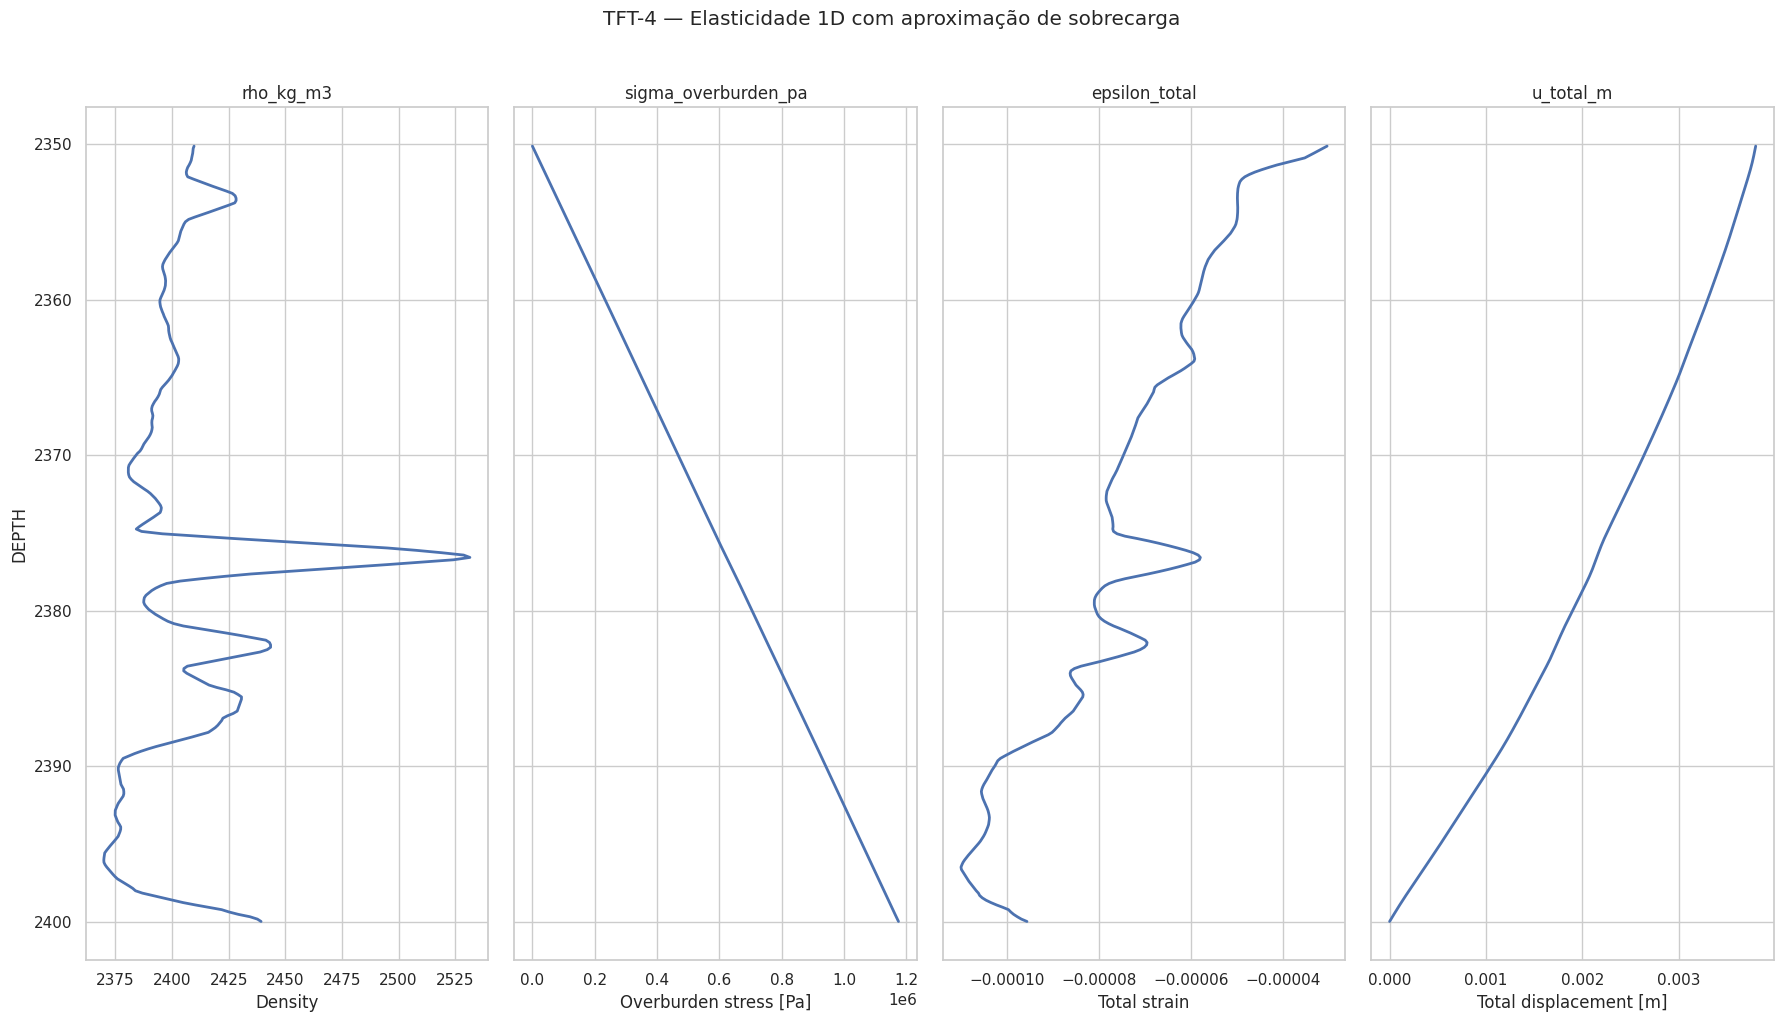


## Interpretação — efeito de sobrecarga

Adicionamos uma estimativa simples de tensão por peso próprio:

```text
d_sigma = rho * g * dz
```

### Resultado

- Tensão de sobrecarga máxima dentro da zona: **1.175e+06 Pa**
- Deslocamento total no topo: **3.798349e-03 m**

### Como interpretar

A sobrecarga aumenta a compressão com a profundidade local da zona.

Como a zona tem dezenas de metros, esse efeito é pequeno comparado ao peso total da coluna desde a superfície, mas já ajuda a introduzir o conceito.

### Conclusão

Este é um passo intermediário entre elasticidade simples e geomecânica mais realista.


In [12]:
g = 9.80665

if "rho_kg_m3" in result_df.columns and result_df["rho_kg_m3"].notna().any():
    rho = result_df["rho_kg_m3"].to_numpy(dtype=float)
    sigma_overburden = np.zeros_like(x)

    for i in range(1, len(x)):
        dx = x[i] - x[i - 1]
        rho_avg = 0.5 * (rho[i] + rho[i - 1])
        sigma_overburden[i] = sigma_overburden[i - 1] + rho_avg * g * dx

    result_df["sigma_overburden_pa"] = sigma_overburden
    result_df["sigma_total_pa"] = APPLIED_TOP_STRESS_PA - sigma_overburden

    result_df["epsilon_total"] = result_df["sigma_total_pa"] / result_df["E_pa"]

    u_total = np.zeros_like(x)
    u_total[-1] = BASE_DISPLACEMENT_M

    eps_total = result_df["epsilon_total"].to_numpy(dtype=float)

    for i in range(len(x) - 2, -1, -1):
        dx = x[i + 1] - x[i]
        eps_avg = 0.5 * (eps_total[i + 1] + eps_total[i])
        u_total[i] = u_total[i + 1] - eps_avg * dx

    result_df["u_total_m"] = u_total

    fig, axes = plt.subplots(1, 4, figsize=(18, 10), sharey=True)

    axes[0].plot(result_df["rho_kg_m3"], result_df["DEPTH"], "-", linewidth=2)
    axes[0].set_title("rho_kg_m3")
    axes[0].set_xlabel("Density")

    axes[1].plot(result_df["sigma_overburden_pa"], result_df["DEPTH"], "-", linewidth=2)
    axes[1].set_title("sigma_overburden_pa")
    axes[1].set_xlabel("Overburden stress [Pa]")

    axes[2].plot(result_df["epsilon_total"], result_df["DEPTH"], "-", linewidth=2)
    axes[2].set_title("epsilon_total")
    axes[2].set_xlabel("Total strain")

    axes[3].plot(result_df["u_total_m"], result_df["DEPTH"], "-", linewidth=2)
    axes[3].set_title("u_total_m")
    axes[3].set_xlabel("Total displacement [m]")

    for ax in axes:
        ax.grid(True)

    axes[0].invert_yaxis()
    axes[0].set_ylabel("DEPTH")
    fig.suptitle(f"{WELL_NAME} — Elasticidade 1D com aproximação de sobrecarga", y=1.02)
    plt.tight_layout()
    plt.show()

    display(Markdown(f'''
## Interpretação — efeito de sobrecarga

Adicionamos uma estimativa simples de tensão por peso próprio:

```text
d_sigma = rho * g * dz
```

### Resultado

- Tensão de sobrecarga máxima dentro da zona: **{result_df["sigma_overburden_pa"].max():,.3e} Pa**
- Deslocamento total no topo: **{result_df["u_total_m"].iloc[0]:,.6e} m**

### Como interpretar

A sobrecarga aumenta a compressão com a profundidade local da zona.

Como a zona tem dezenas de metros, esse efeito é pequeno comparado ao peso total da coluna desde a superfície, mas já ajuda a introduzir o conceito.

### Conclusão

Este é um passo intermediário entre elasticidade simples e geomecânica mais realista.
'''))
else:
    print("Campo rho_kg_m3 indisponível. Pulando estimativa de sobrecarga.")

# STEP 11 — Export Simulation Results

Agora salvamos o resultado da simulação 1D.

Saída:

```text
data/simulation/parquet/single_well_elasticity_1d/
```

Este arquivo poderá ser usado depois para comparar diferentes zonas, tensões aplicadas ou modelos.

In [13]:
safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")
simulation_path = DATA_SIMULATION_DIR / f"{safe_well_name}_elasticity_1d_simulation.parquet"

result_df.to_parquet(simulation_path, index=False)

summary_path = REPORT_DIR / f"{safe_well_name}_elasticity_1d_summary.csv"
summary.to_csv(summary_path, index=False)

column_dictionary = pd.DataFrame({
    "COLUMN": result_df.columns,
    "DTYPE": [str(result_df[c].dtype) for c in result_df.columns],
    "NON_NULL_COUNT": [result_df[c].notna().sum() for c in result_df.columns],
    "NULL_COUNT": [result_df[c].isna().sum() for c in result_df.columns],
    "FILL_RATE": [result_df[c].notna().mean() for c in result_df.columns],
})

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_elasticity_1d_column_dictionary.csv"
column_dictionary.to_csv(column_dictionary_path, index=False)

print("SIMULAÇÃO EXPORTADA COM SUCESSO!")
print(f"Arquivo parquet: {simulation_path}")
print(f"Resumo: {summary_path}")
print(f"Dicionário: {column_dictionary_path}")

display(summary)
display(column_dictionary)

SIMULAÇÃO EXPORTADA COM SUCESSO!
Arquivo parquet: ../data/simulation/parquet/single_well_elasticity_1d/TFT-4_elasticity_1d_simulation.parquet
Resumo: ../reports/single_well_elasticity_1d/TFT-4_elasticity_1d_summary.csv
Dicionário: ../reports/single_well_elasticity_1d/TFT-4_elasticity_1d_column_dictionary.csv


,WELL,N_POINTS,L_M,APPLIED_TOP_STRESS_PA,BASE_DISPLACEMENT_M,U_TOP_M,U_BASE_M,MAX_ABS_U_M,EPSILON_MIN,EPSILON_MAX,E_MIN_PA,E_MAX_PA
0,TFT-4,329,49.856000,"-1,000,000.000000",0.000000,0.002377,0.000000,0.002377,-0.000053,-0.000031,"18,722,214,064.785511","32,786,153,018.229519"


,COLUMN,DTYPE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE
0,WELL,str,329,0,1.000000
1,DEPTH,float64,329,0,1.000000
2,rho_kg_m3,float64,329,0,1.000000
3,vp_mps,float64,329,0,1.000000
4,vs_mps,float64,329,0,1.000000
5,nu,float64,329,0,1.000000
6,G_pa,float64,329,0,1.000000
7,K_pa,float64,329,0,1.000000
8,E_pa,float64,329,0,1.000000
9,ai,float64,329,0,1.000000


# STEP 12 — FEniCS / FEniCSx Bridge

Este notebook usou um solver NumPy didático.

Mas a ponte para FEniCS é natural.

## O que o FEniCS faria?

Em vez de integrar manualmente:

```text
epsilon = sigma / E
```

ele resolveria a formulação fraca da elasticidade.

## Forma forte simplificada 1D

```text
-d/dx( E(x) du/dx ) = f(x)
```

## Forma fraca

Encontrar `u` tal que:

```text
∫ E(x) du/dx dv/dx dx = ∫ f v dx + termos de contorno
```

## O que entra no FEniCS

Do Parquet physics-ready:

```text
x
E(x)
nu(x)
rho(x)
G(x)
K(x)
```

## Próximo passo

O próximo notebook pode ser:

```text
05B_single_well_fenicsx_elasticity_1d.ipynb
```

ou podemos seguir para:

```text
05B_single_well_poroelasticity_1d.ipynb
```

Mas a recomendação é validar bem este 05A primeiro.

# Conclusão do Notebook 05A

Você acabou de fechar a primeira simulação mecânica 1D do poço.

O caminho completo agora ficou:

```text
LAS bruto
↓
QC
↓
Feature Engineering
↓
Analytics
↓
Physics Preparation
↓
Elasticity Simulation
```

## O que este notebook já responde

- Como a zona responde a uma carga compressiva simples?
- Onde a deformação é maior?
- Como `E(z)` controla a deformação?
- A zona é mecanicamente estável para uma primeira simulação?
- Os campos físicos preparados no notebook 04 fazem sentido numericamente?

## Próxima evolução

Depois de rodar e interpretar este notebook:

```text
05B — Poroelasticidade 1D
```

Aí começaremos a acoplar:

```text
pressão + deformação
```